# Boston Housing â€” exploration for Lab 1 (k-NN Regression)

Purely exploratory, to justify what we saw running the C++ `KNNRegression` in the app (Tasks 5-7): the mediocre RÂ² (~0.38 on test with Euclidean) and why switching to Manhattan barely moved it. `scikit-learn` here is only a fast reference for sweeping `k`/metric/scaling combinations we can't easily automate by hand in the UI â€” the graded implementation stays the C++ one.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

df = pd.read_csv("../BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


## 1. Sanity check

In [2]:
print(df.info())
print("\nMissing values per column:\n", df.isnull().sum())
df.describe().T

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB
None

Missing values per column:
 crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64


,count,mean,std,min,25%,50%,75%,max
crim,506.0,3.613524,8.601545,0.00632,0.082045,0.25651,3.677083,88.9762
zn,506.0,11.363636,23.322453,0.00000,0.000000,0.00000,12.500000,100.0000
indus,506.0,11.136779,6.860353,0.46000,5.190000,9.69000,18.100000,27.7400
chas,506.0,0.069170,0.253994,0.00000,0.000000,0.00000,0.000000,1.0000
nox,506.0,0.554695,0.115878,0.38500,0.449000,0.53800,0.624000,0.8710
rm,506.0,6.284634,0.702617,3.56100,5.885500,6.20850,6.623500,8.7800
age,506.0,68.574901,28.148861,2.90000,45.025000,77.50000,94.075000,100.0000
dis,506.0,3.795043,2.105710,1.12960,2.100175,3.20745,5.188425,12.1265
rad,506.0,9.549407,8.707259,1.00000,4.000000,5.00000,24.000000,24.0000
tax,506.0,408.237154,168.537116,187.00000,279.000000,330.00000,666.000000,711.0000


## 2. Feature scale â€” the core of the Euclidean-vs-Manhattan discussion

This is the number that backs up the maths we worked through: `tax` and `b` have a range in the hundreds, `nox`/`chas` a range around 1. Any distance metric that sums raw per-feature differences (Euclidean *or* Manhattan) lets the large-range features dominate â€” this plot is the empirical version of that argument.

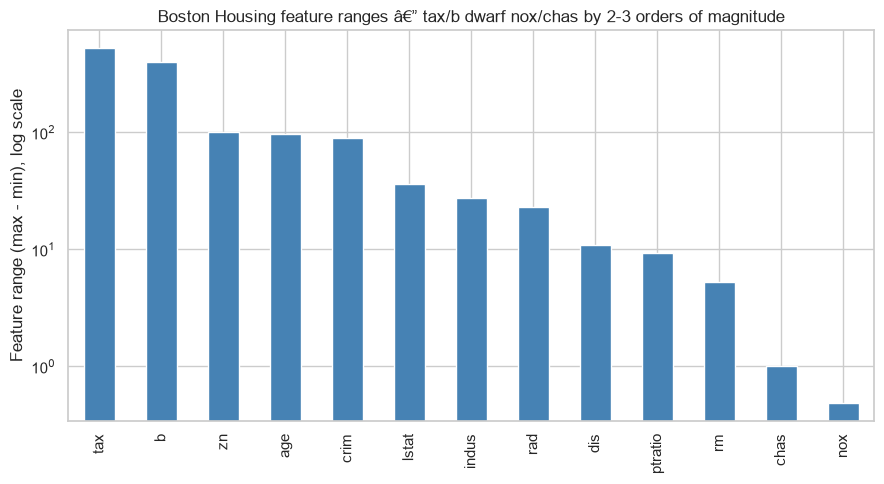

In [3]:
feature_cols = [c for c in df.columns if c != "medv"]
ranges = (df[feature_cols].max() - df[feature_cols].min()).sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ranges.plot(kind="bar", color="steelblue")
plt.yscale("log")
plt.ylabel("Feature range (max - min), log scale")
plt.title(
    "Boston Housing feature ranges â€” tax/b dwarf nox/chas by 2-3 orders of magnitude"
)
plt.tight_layout()
plt.show()

## 3. Which features actually correlate with `medv`?

The scale of a feature says nothing about how informative it is â€” `rm` and `lstat` typically matter far more than their raw range would suggest, which is exactly the problem: an unscaled distance metric weights by range, not by relevance.

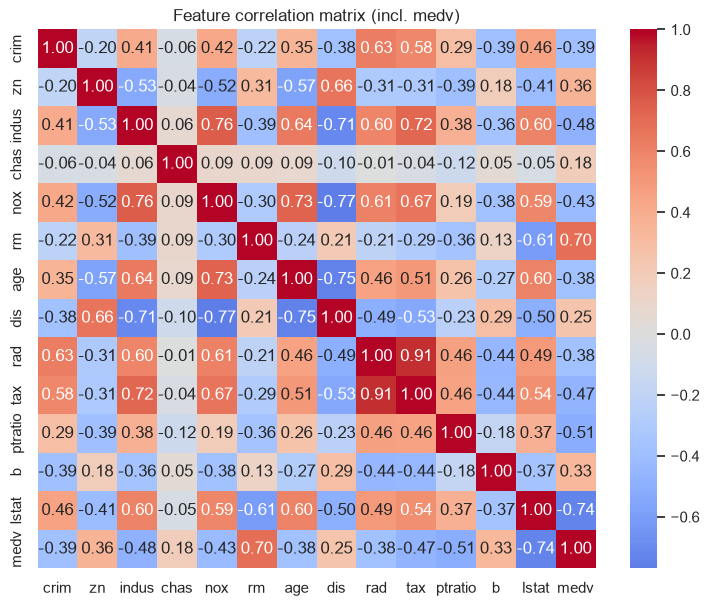

Correlation with medv, sorted by |value|:
lstat      0.737663
rm         0.695360
ptratio    0.507787
indus      0.483725
tax        0.468536
nox        0.427321
crim       0.388305
rad        0.381626
age        0.376955
zn         0.360445
b          0.333461
dis        0.249929
chas       0.175260
Name: medv, dtype: float64


In [4]:
corr = df.corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature correlation matrix (incl. medv)")
plt.show()

print("Correlation with medv, sorted by |value|:")
print(corr["medv"].drop("medv").abs().sort_values(ascending=False))

## 4. Quantifying the fix: raw vs scaled features

The claim from our discussion was "changing the distance formula alone won't fix the scale problem, normalizing the features would." Let's actually measure that instead of just asserting it â€” same train/test split, same `k`, only the scaling changes.

In [5]:
X = df[feature_cols].to_numpy()
y = df["medv"].to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

scaler = StandardScaler().fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)


def r2_for(metric: str, k: int, X_tr, X_te) -> float:
    model = KNeighborsRegressor(n_neighbors=k, metric=metric)
    model.fit(X_tr, y_train)
    return model.score(X_te, y_test)


results = pd.DataFrame(
    {
        "euclidean, raw": [
            r2_for("euclidean", k, X_train, X_test) for k in [1, 3, 5, 7, 11, 15, 21]
        ],
        "manhattan, raw": [
            r2_for("manhattan", k, X_train, X_test) for k in [1, 3, 5, 7, 11, 15, 21]
        ],
        "euclidean, scaled": [
            r2_for("euclidean", k, X_train_scaled, X_test_scaled)
            for k in [1, 3, 5, 7, 11, 15, 21]
        ],
        "manhattan, scaled": [
            r2_for("manhattan", k, X_train_scaled, X_test_scaled)
            for k in [1, 3, 5, 7, 11, 15, 21]
        ],
    },
    index=pd.Index([1, 3, 5, 7, 11, 15, 21], name="k"),
)
results.round(3)

,"euclidean, raw","manhattan, raw","euclidean, scaled","manhattan, scaled"
k,,,,
1,0.418,0.530,0.660,0.749
3,0.705,0.666,0.735,0.744
5,0.647,0.700,0.719,0.708
7,0.597,0.649,0.681,0.690
11,0.507,0.624,0.663,0.674
15,0.500,0.603,0.643,0.673
21,0.472,0.566,0.628,0.636


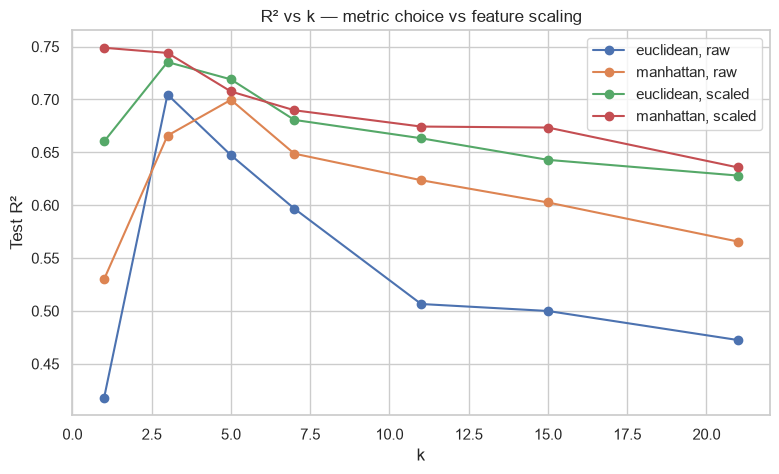

In [6]:
results.plot(marker="o", figsize=(9, 5))
plt.ylabel("Test R\u00b2")
plt.xlabel("k")
plt.title("R\u00b2 vs k \u2014 metric choice vs feature scaling")
plt.legend()
plt.show()

**Expected pattern**: the two "raw" columns (euclidean/manhattan) should sit close together and clearly below the two "scaled" columns, which should also sit close together â€” i.e. **scaling moves the result far more than the choice of metric does**. That's the concrete evidence for the mathematical argument made in the C++ implementation discussion (squaring amplifies the dominance of `tax`/`b`, Manhattan mitigates it slightly, only scaling actually fixes it). Good numbers to bring to the demo if asked to justify the metric choice.

## 5. Full k sweep matching the app — Manhattan, raw (same setup as the current C++ `KNNRegression`)

Reproduces exactly what the app's Train/Test Evaluation panels show (RMSE, MAE, R², train **and** test), for the same k values worth testing by hand in the UI (Task 7): 1, 2, 3, 4, 5, 8, 11, 20, 50. Same distance metric currently wired in `KNNRegression.cpp` (Manhattan), no scaling — this is the direct point of comparison for manual app runs, not the scaled/best-case numbers from section 4."

In [7]:
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error

k_values_app = [1, 2, 3, 4, 5, 8, 11, 20, 50]
rows = []
for k in k_values_app:
    model = KNeighborsRegressor(n_neighbors=k, metric="manhattan")
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    rows.append(
        {
            "k": k,
            "train_rmse": root_mean_squared_error(y_train, train_pred),
            "train_mae": mean_absolute_error(y_train, train_pred),
            "train_r2": r2_score(y_train, train_pred),
            "test_rmse": root_mean_squared_error(y_test, test_pred),
            "test_mae": mean_absolute_error(y_test, test_pred),
            "test_r2": r2_score(y_test, test_pred),
        }
    )
app_comparison = pd.DataFrame(rows).set_index("k")
app_comparison.round(3)

,train_rmse,train_mae,train_r2,test_rmse,test_mae,test_r2
k,,,,,,
1,0.000,0.000,1.000,5.871,3.770,0.530
2,3.287,2.113,0.876,4.544,3.276,0.718
3,4.159,2.782,0.801,4.950,3.361,0.666
4,4.476,3.067,0.769,4.662,3.385,0.704
5,4.849,3.294,0.729,4.693,3.330,0.700
8,5.199,3.556,0.689,5.162,3.469,0.637
11,5.708,3.882,0.625,5.253,3.511,0.624
20,6.636,4.487,0.493,5.550,3.646,0.580
50,7.740,5.499,0.310,6.788,4.739,0.372


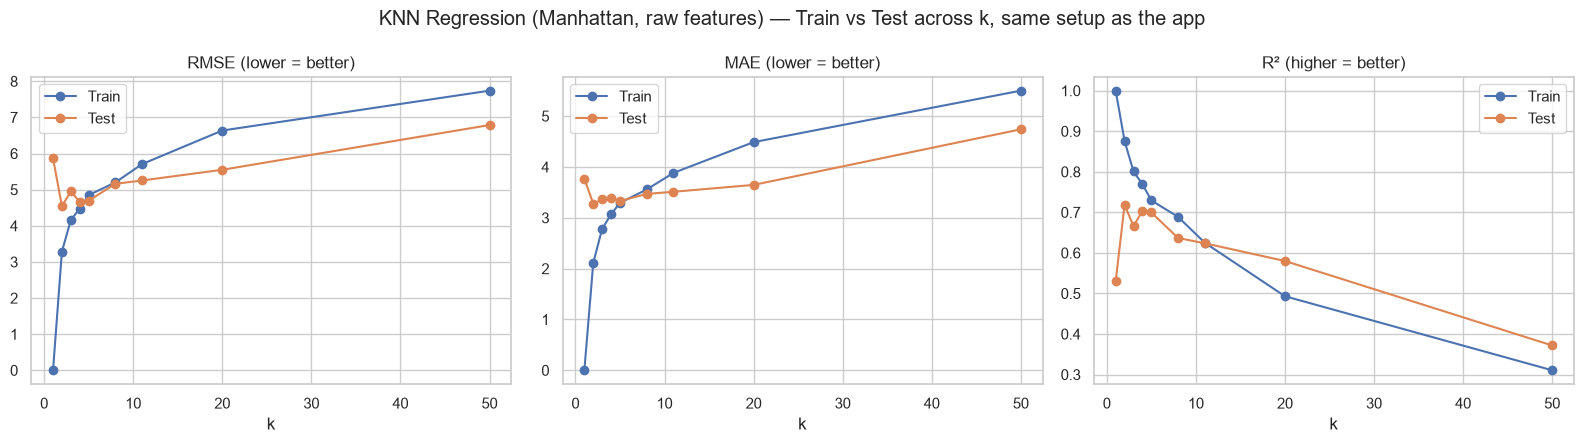

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

for ax, metric, title in zip(
    axes, ["rmse", "mae", "r2"], ["RMSE (lower = better)", "MAE (lower = better)", "R² (higher = better)"]
):
    ax.plot(app_comparison.index, app_comparison[f"train_{metric}"], marker="o", label="Train")
    ax.plot(app_comparison.index, app_comparison[f"test_{metric}"], marker="o", label="Test")
    ax.set_xlabel("k")
    ax.set_title(title)
    ax.legend()

fig.suptitle("KNN Regression (Manhattan, raw features) — Train vs Test across k, same setup as the app")
plt.tight_layout()
plt.show()